In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
!pip install shap
import shap

import tensorflow as tf
from tensorflow import keras
!pip install scikeras
from scikeras.wrappers import KerasClassifier

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

In [ ]:
data=pd.concat([y,X],axis=1)
data['income'] = data['income'].str.replace('.', '', regex=False)
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,<=50K,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,<=50K,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,<=50K,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,<=50K,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,<=50K,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
data.dropna(inplace=True)
data.shape

(47621, 15)

In [ ]:
data = data.sample(n=10000, random_state=42)

data['education'] = data['education'].replace(['11th', '10th', '9th', '12th'], 'HS-no_grad')
data['education'] = data['education'].replace(['Preschool','1st-4th', '5th-6th', '7th-8th'], 'Grade_school')
data['workclass'] = data['workclass'].replace(['Local-gov', 'State-gov', 'Federal-gov'], 'Gov-jobs')
data['workclass'] = data['workclass'].replace(['Self-emp-not-inc', 'Self-emp-inc'], 'Self-employed')
data['marital-status']=data['marital-status'].replace(['Divorced', 'Separated'], 'No-longer-married')
data = data.replace('?', 'Undisclosed')
data['native-country'] = data['native-country'].apply(lambda x: x if x in ['United-States', 'Mexico'] else 'Other-country')
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1536,<=50K,34,Private,122116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
20190,<=50K,36,Gov-jobs,223020,Some-college,10,No-longer-married,Other-service,Unmarried,Black,Female,0,0,20,United-States
47437,<=50K,59,Self-employed,165867,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,25,United-States
10192,>50K,59,Private,453067,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,36,United-States
38494,>50K,36,Private,49657,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States


In [ ]:
obj_data=data.loc[:,['sex','workclass','education','marital-status','occupation','relationship','race','native-country']]
data.drop(columns=['sex','workclass','education','marital-status','occupation','relationship','race','native-country'],inplace=True)

obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})

encoder = LabelEncoder()
for col in data.select_dtypes("object"):
    data[col] =encoder.fit_transform(data[[col]])

X=data.drop(columns=['income'])
X=pd.concat([X,obj_data],axis=1)
X = X.astype(float)
y=data['income']
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_Other-country,fet_United-States
1536,34.0,122116.0,10.0,0.0,0.0,40.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
20190,36.0,223020.0,10.0,0.0,0.0,20.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
47437,59.0,165867.0,13.0,0.0,0.0,25.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
10192,59.0,453067.0,10.0,0.0,0.0,36.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
38494,36.0,49657.0,13.0,0.0,0.0,50.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


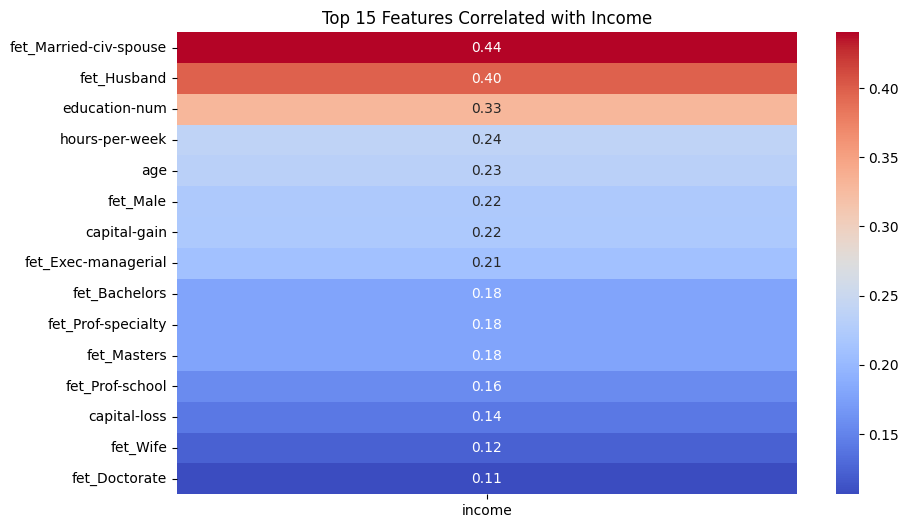

In [ ]:
sns.set_palette("pastel")

plt.figure(figsize=(10,6))
data2=pd.concat([y,X],axis=1)

correlations = data2.corr()['income'].sort_values(ascending=False)

# Select top 15 features
top_15_features = correlations[1:16]  # Exclude 'income' itself

top_15_corr_df = pd.DataFrame(top_15_features)
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

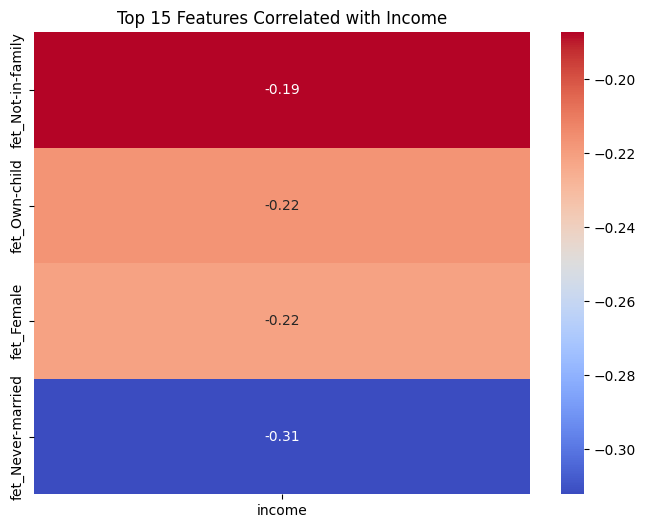

In [ ]:
plt.figure(figsize=(8,6))
top_15_corr_df = pd.DataFrame(correlations[55:59])
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

In [ ]:
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)
X_train.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_Other-country,fet_United-States
40198,-1.315462,2.579025,-0.435755,-0.146619,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
45664,1.350715,0.020306,-0.435755,-0.146619,-0.210876,-0.062394,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
3918,0.610110,-1.061531,-0.435755,-0.146619,-0.210876,0.763030,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
15653,-0.204555,-0.372319,-0.435755,-0.146619,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
18365,-0.130495,0.064007,-0.046688,0.174551,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,3.516957,-3.086473


In [ ]:
model_1 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_1.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7895 - loss: 0.4243 - val_accuracy: 0.8294 - val_loss: 0.3566
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8401 - loss: 0.3300 - val_accuracy: 0.8425 - val_loss: 0.3470
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8493 - loss: 0.3182 - val_accuracy: 0.8363 - val_loss: 0.3495
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8635 - loss: 0.2897 - val_accuracy: 0.8400 - val_loss: 0.3446
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8696 - loss: 0.2758 - val_accuracy: 0.8338 - val_loss: 0.3494
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8781 - loss: 0.2697 - val_accuracy: 0.8331 - val_loss: 0.3512
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8752 - loss: 0.2669 - val_accuracy: 0.8381 - val_loss: 0.3635
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8721 - loss: 0.2708 - val_accuracy: 0.

In [ ]:

def create_model(num_layers=1, num_neurons=64, activation='relu', optimizer='adam', dropout_rate=0.0,
                 l2_reg=0.0):
    model = keras.Sequential()
    model.add(keras.layers.Dense(num_neurons, activation=activation, input_shape=(X_train.shape[1],),
                                kernel_regularizer=keras.regularizers.l2(l2_reg)))
    model.add(keras.layers.Dropout(dropout_rate))
    for _ in range(num_layers - 1):
        model.add(keras.layers.Dense(num_neurons, activation=activation,
                                    kernel_regularizer=keras.regularizers.l2(l2_reg)))
        model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = KerasClassifier(build_fn=create_model, verbose=0)


param_dist = {
    'model__num_layers': [1, 2, 3],
    'model__num_neurons': [32, 64, 128],
    'model__activation': ['relu', 'tanh'],
    'model__optimizer': ['adam', 'rmsprop'],
    'model__dropout_rate': [0.0, 0.2, 0.4],
    'model__l2_reg': [0.0, 0.001, 0.01],
    'epochs': [10, 20, 30],
    'batch_size': [32, 64]
}


random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

best_model2 = random_search.best_estimator_

Best parameters: {'model__optimizer': 'adam', 'model__num_neurons': 64, 'model__num_layers': 2, 'model__l2_reg': 0.01, 'model__dropout_rate': 0.0, 'model__activation': 'relu', 'epochs': 20, 'batch_size': 64}
Best score: 0.8442501045208809


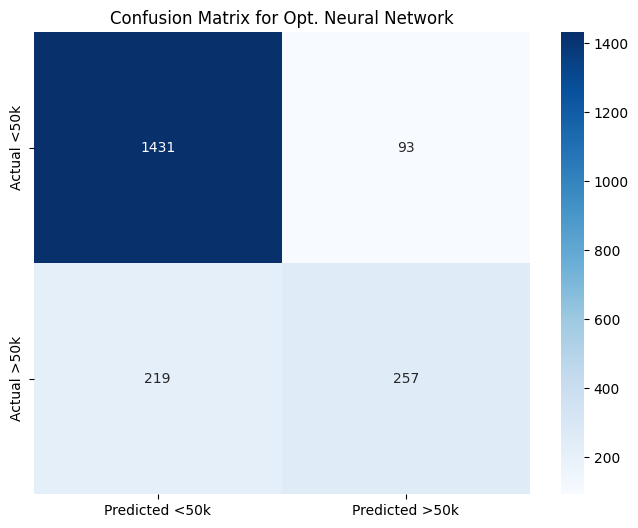

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = best_model2.predict(X_test)


y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted <50k', 'Predicted >50k'],
            yticklabels=['Actual <50k', 'Actual >50k'])
plt.title("Confusion Matrix for Opt. Neural Network")
plt.show()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8935 - loss: 0.2288
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


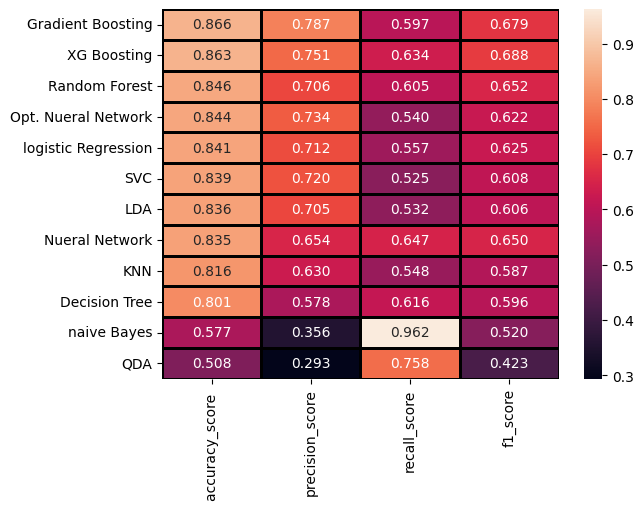

In [ ]:
model_dic={
    'Opt. Nueral Network':best_model2,
    'Nueral Network':model_1,
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    "Decision Tree":DTC(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)
        y_pred = model.predict(X_test.to_numpy())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if i in ['Opt. Nueral Network', 'Nueral Network']:
            y_pred = (y_pred > 0.5).astype(int)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1, fmt=".3f")
plt.show()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8916 - loss: 0.2365
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


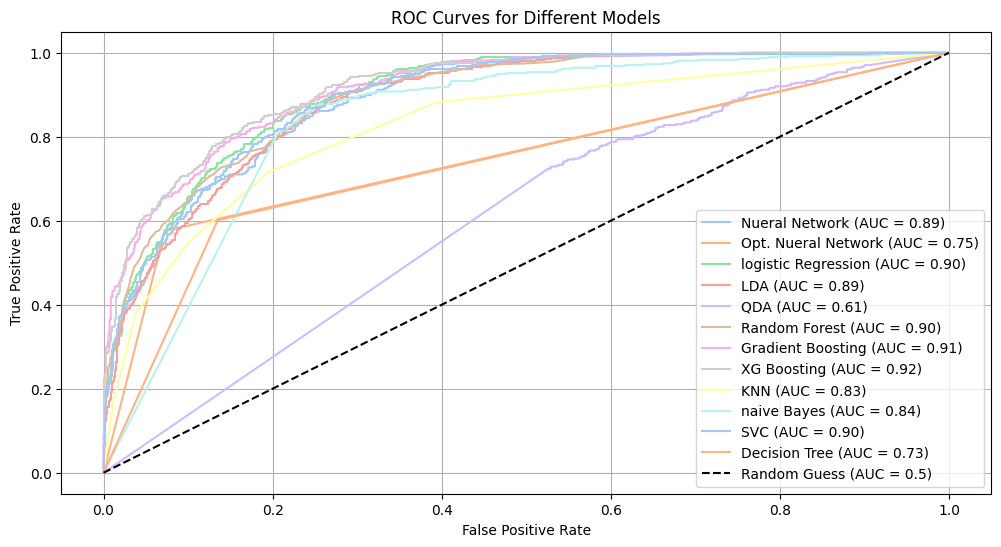

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

plt.figure(figsize=(12,6))

model_dic={
    'Nueral Network':model_1,
    'Opt. Nueral Network':best_model2,
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear',probability=True),
    "Decision Tree":DTC()
}
for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)
        y_score = model.predict_proba(X_test.to_numpy())[:, 1]
    elif i in ['Nueral Network', 'Opt. Nueral Network']:
        if i == 'Nueral Network':
            model.fit(X_train, y_train)

        y_score = model.predict(X_test)
        if isinstance(y_score, list) and len(y_score) > 0 and isinstance(y_score[0], np.ndarray):
            y_score = y_score[0]

        y_score = y_score.ravel() if y_score.ndim > 1 else y_score

    else:
        model.fit(X_train,y_train)
        y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()

The optimal number of neighbors is 15 with an average training accuracy of 0.8245


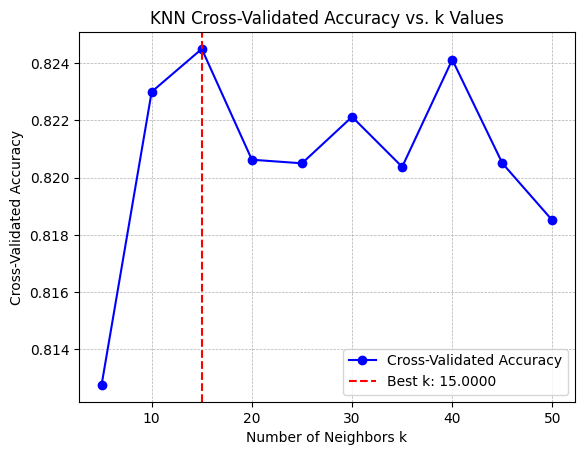

In [ ]:
k_values = range(5, 55, 5)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of neighbors is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Cross-Validated Accuracy vs. k Values')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
param_dist = {
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
    'p': [1, 2, 3],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [11,14,17],
}

knn = KNeighborsClassifier(n_neighbors=15)

# Randomized search with 10 iterations
random_search = RandomizedSearchCV(knn, param_dist, n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=101)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'weights': 'uniform', 'p': 2, 'metric': 'manhattan', 'leaf_size': 17, 'algorithm': 'ball_tree'}
Best Accuracy: 0.8237500882532219


The optimal number of estimators is 300 with an average training accuracy of 0.8440


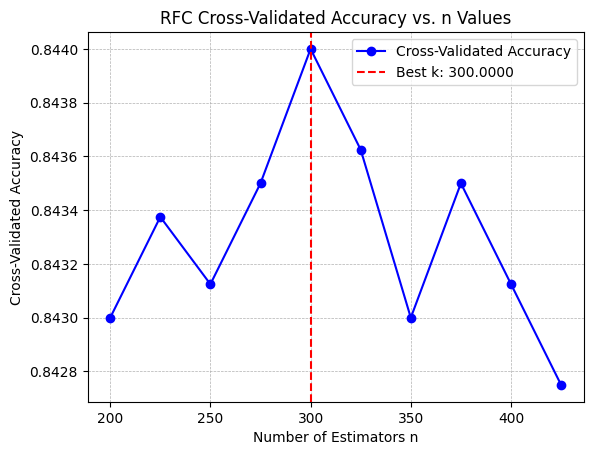

In [ ]:
k_values = range(200,450, 25)
cv_scores = []

for k in k_values:
    rfc = RandomForestClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(rfc, X_train, y_train, cv=3, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Number of Estimators n')
plt.ylabel('Cross-Validated Accuracy')
plt.title('RFC Cross-Validated Accuracy vs. n Values')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
param_dist = {
    'max_depth': [15,20,25],
    'min_samples_split': [20,30,40,50],
    'min_samples_leaf': [1,2,3,4,5],
}

rf = RandomForestClassifier(n_estimators=300,random_state=101)

random_search = RandomizedSearchCV(rf, param_dist, n_iter=50, cv=3, scoring='accuracy', n_jobs=-1, random_state=101)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': 25}
Best Accuracy: 0.855125339265075


In [ ]:
feature_importances = pd.DataFrame(random_search.best_estimator_.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
print(feature_importances.head(5))

                        importance
capital-gain              0.140667
fet_Married-civ-spouse    0.120238
education-num             0.112189
fet_Husband               0.088393
age                       0.084752


The optimal number of estimators is 3 with an average accuracy of 0.8607


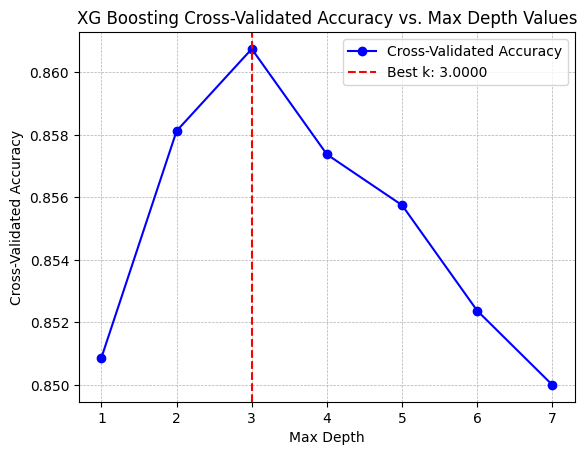

In [ ]:
k_values = range(1, 8)
cv_scores = []

for k in k_values:
    xg = XGBClassifier(max_depth=k)
    scores = cross_val_score(xg, X_train.to_numpy(), y_train.to_numpy(), cv=3, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validated Accuracy')
plt.title('XG Boosting Cross-Validated Accuracy vs. Max Depth Values')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

The optimal number of estimators is 90 with an average accuracy of 0.8610


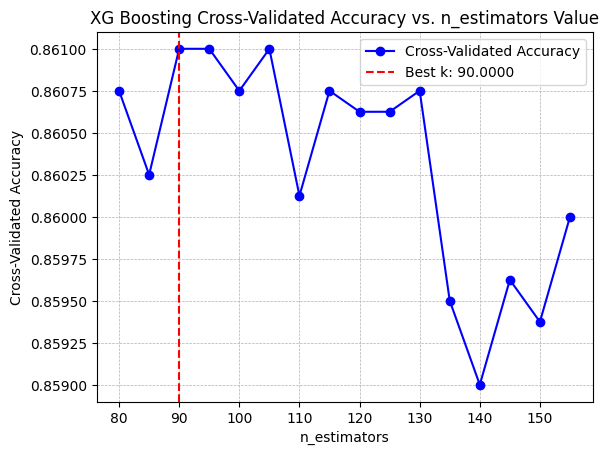

In [ ]:
k_values = range(80,160,5)
cv_scores = []

for k in k_values:
    xg = XGBClassifier(n_estimators=k,max_depth=3)
    scores = cross_val_score(xg, X_train.to_numpy(), y_train.to_numpy(), cv=3, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Cross-Validated Accuracy')
plt.title('XG Boosting Cross-Validated Accuracy vs. n_estimators Value')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
xg = XGBClassifier(max_depth=3,n_estimators=90,random_state=101)

param_dist = {
    'learning_rate': [0.15,0.3,0.5],
    'min_child_weight': [2,3,4],
    'subsample': [0.6,0.8,1],
    'colsample_bytree': [0.4,0.6,0.8],
    'gamma': [0.005,0.01,0.03],
    'reg_alpha': [0.01,0.005,0.1],
    'reg_lambda': [0.005,0.01,0.05],
    'tree_method': ['auto']
}


random_search = RandomizedSearchCV(xg, param_dist, n_iter=100, cv=5, scoring='accuracy', n_jobs=-1)
# Convert X_train to NumPy array before fitting
random_search.fit(X_train.to_numpy(), y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best accuracy score: {random_search.best_score_}")

Best parameters: {'tree_method': 'auto', 'subsample': 1, 'reg_lambda': 0.05, 'reg_alpha': 0.1, 'min_child_weight': 3, 'learning_rate': 0.3, 'gamma': 0.005, 'colsample_bytree': 0.4}
Best accuracy score: 0.8616249999999999


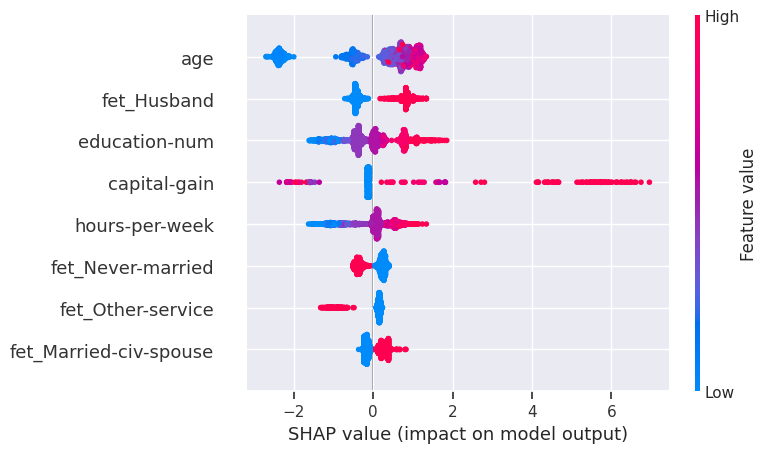

In [ ]:
sns.set(style="darkgrid")
sns.set_palette("pastel")

model = XGBClassifier(n_estimators=90,tree_method='auto',subsample=1,reg_lambda=0.05,reg_alpha=0.1,min_child_weight=3,max_depth=3,learning_rate=0.3,gamma=0.005,colsample_bytree=0.4)
model.fit(X_train.to_numpy(), y_train.to_numpy())

explainer = shap.Explainer(model, X_train.to_numpy()) # Convert to Numpy array
shap_values = explainer(X_test.to_numpy())

shap.summary_plot(shap_values, X_test, max_display=8)

In [ ]:
clf=DTC(criterion='entropy',random_state=101)
clf.fit(X_train,y_train)
accuracy_score(y_test,clf.predict(X_test))  #test accuracy with no pruning

0.8095

In [ ]:
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
kfold=skm.KFold(5,random_state=101,shuffle=True)
grid=skm.GridSearchCV(clf, {'ccp_alpha':ccp_path.ccp_alphas}, refit=True, cv=kfold, scoring='accuracy')
grid.fit(X_train,y_train)
grid.best_score_

0.843125

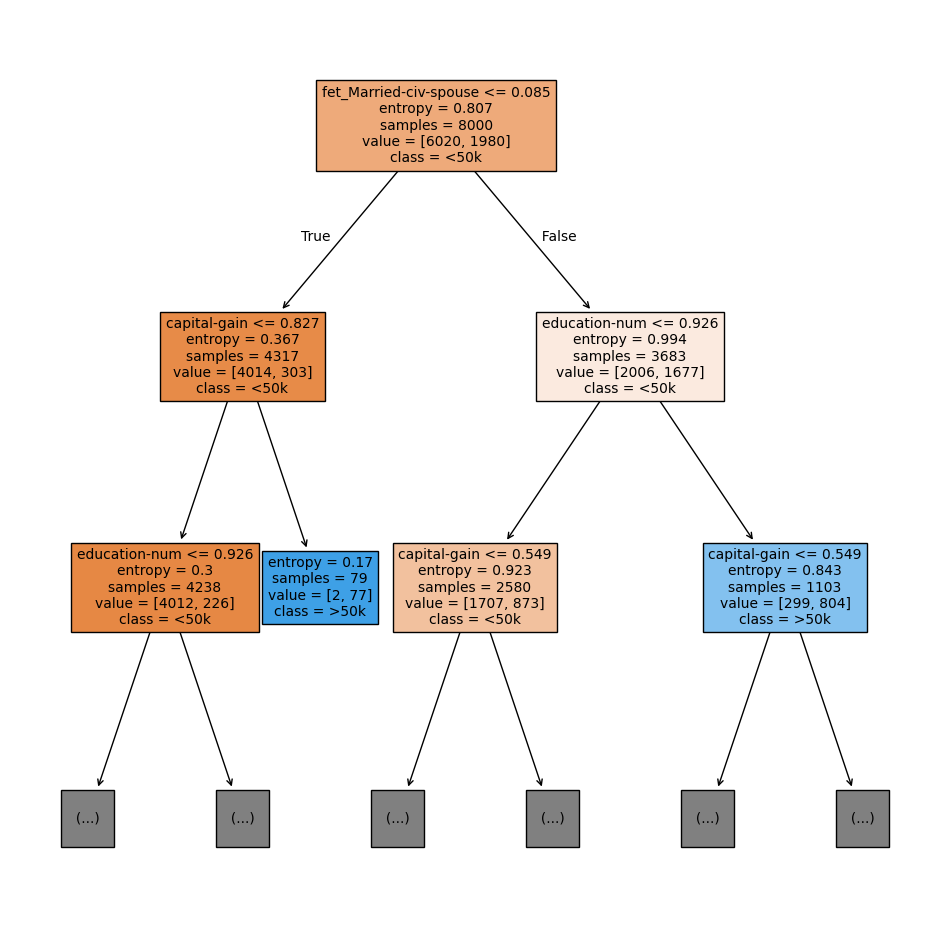

In [ ]:
sns.set_palette("pastel")
best_=grid.best_estimator_
feature_names=list(X_train.columns)
fig, ax=subplots(figsize=(12,12))
plot_tree(best_,max_depth=2,feature_names=feature_names,class_names=['<50k','>50k'],filled=True,ax=ax,fontsize=10)
plt.show()

The optimal number of estimators is 300 with an average accuracy of 0.8584


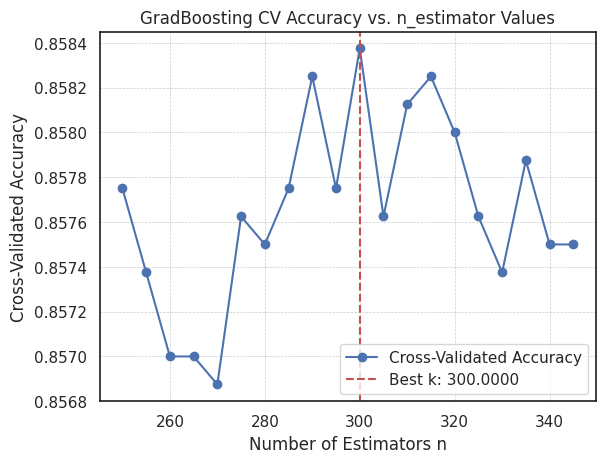

In [ ]:
sns.set_theme(style="white")
k_values = range(250,350,5)
cv_scores = []

for k in k_values:
    gd = GradientBoostingClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(gd, X_train, y_train, cv=5, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Number of Estimators n')
plt.ylabel('Cross-Validated Accuracy')
plt.title('GradBoosting CV Accuracy vs. n_estimator Values')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

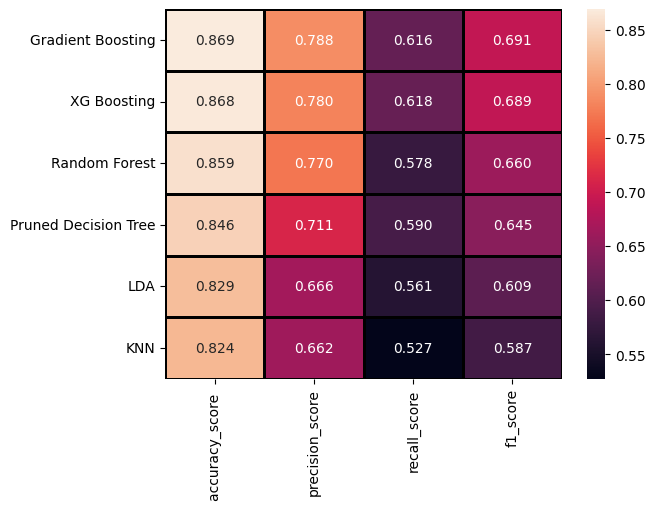

In [ ]:
model_dic={
    'Random Forest':RandomForestClassifier(n_estimators=300,min_samples_split=20,min_samples_leaf=4,max_depth=25),
    "Pruned Decision Tree":best_,
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=300,random_state=101),
    'XG Boosting':XGBClassifier(n_estimators=90,tree_method='auto',subsample=1,reg_lambda=0.05,reg_alpha=0.1,min_child_weight=3,max_depth=3,learning_rate=0.3,gamma=0.005,colsample_bytree=0.4),
    "KNN":KNeighborsClassifier(n_neighbors=15,weights='uniform',metric='manhattan',leaf_size=17,algorithm='ball_tree',p=2),
}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)  # Convert to Numpy array for xGboost
        y_pred = model.predict(X_test.to_numpy())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1, fmt=".3f")
plt.show()

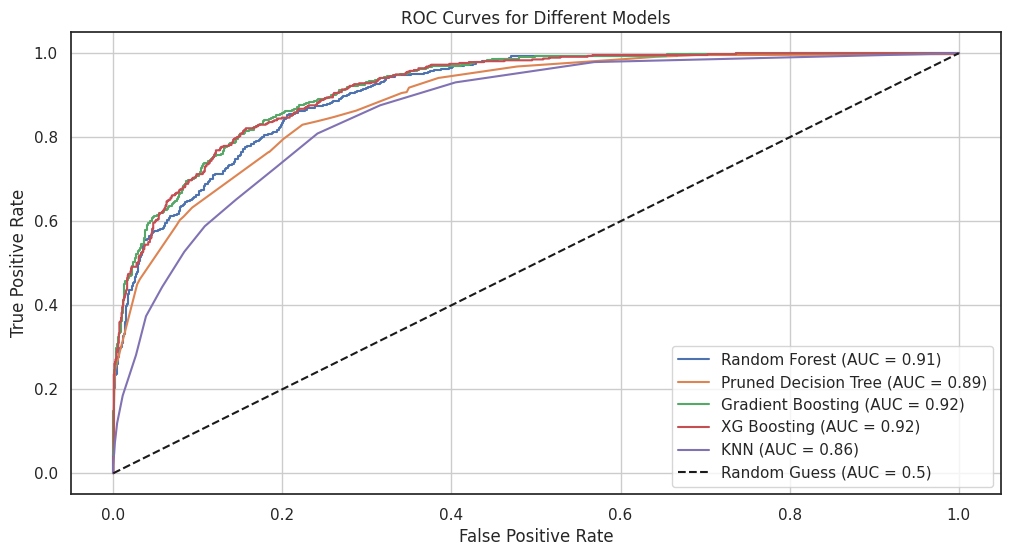

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
plt.figure(figsize=(12,6))

model_dic={
    'Random Forest':RandomForestClassifier(n_estimators=300,min_samples_split=20,min_samples_leaf=4,max_depth=25),
    "Pruned Decision Tree":best_,
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=300,random_state=101),
    'XG Boosting':XGBClassifier(n_estimators=90,tree_method='auto',subsample=1,reg_lambda=0.05,reg_alpha=0.1,min_child_weight=3,max_depth=3,learning_rate=0.3,gamma=0.005,colsample_bytree=0.4),
    "KNN":KNeighborsClassifier(n_neighbors=15,weights='uniform',metric='manhattan',leaf_size=17,algorithm='ball_tree',p=2),
}
for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)
        y_score = model.predict_proba(X_test.to_numpy())[:, 1]
    else:
        model.fit(X_train,y_train)
        y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()